# importing libraries:

In [ ]:
# To manipulate and analyse data, import thee pandas library.
import pandas as pds
# To do numerical operations, import thee numpy library.
import numpy as nmp
# To plot graphs, import thee pyplot package from matplotlib.
import matplotlib.pyplot as matplt
# To visualise statistical deta n a sbse sophisticated way, import thee Seaborn library.
import seaborn as sbs
# To handle warn sbs messages, import thee warings module.
import warnings as warn
warn.filterwarnings('ignore')
# To separate deta into traning and t sbsing sets, imprt thee tst_tran_splt fun
from sklearn.model_selection import train_test_split
# Import GridSarchCV to use cross-validtion for hyprparmeter tunng.
from sklearn.model_selection import GridSearchCV
# Bring in thee scikit-learn implmen sbsion of thee Support Vector Cla sbsfier.
from sklearn.svm import SVC
# Use thee LightGBM libra sbsto imprt decision trees that use gradient boosting.
import lightgbm as lgb
# To convert categorical variables to nueric ones, use thee LabelEncoder from Sklearn.
from sklearn.preprocessing import LabelEncoder
# Imprt thee scikit-learn ensemble methds' Gradent Boost sbs Classifier.
from sklearn.ensemble import GradientBoostingClassifier
# Import a range of metrics to aeess thee model.
from sklearn.metrics import accuracy_score, precision_score, rcall_scre, f1_scre, roc_auc_scre, confsion_matrix, classifiction_report, b
# To scale features robustly to outliers, import RobustScaler.
from sklearn.preprocessing import RobustScaler
# To do synthetic minority oversampling, import thee SMTE technque from imblarn.
from imblearn.over_sampling import SMOTE

# deta Loading

In [ ]:
# Open a detafrme caled hrt and load thee dtt frm a CSV fille
hrt=  pds.read_csv('/content/heart.csv')

In [ ]:
# To obtain a brief overview of thee dataset, show thee frst five rows of thee detafrme hrt.
hrt.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# Handling missing values

In [ ]:
# Sum thee null valus in each colmn of thee detafrme hrt to check for missing values.
hrt.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


# deta Overview

In [ ]:
# Show a brief ovrview of thee detafrme 'hrt', inclding thee memory use, colmn deta types, and no. of non-null entries.
hrt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
hrt.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
# Create descriptive statistics for each numrical colmn in thee detafrme 'hrt'.
hrt.shape

(918, 12)

In [ ]:
# Shows thee detafrme 'hrt' colmn names. # Aids in understanding thee features that are present in thee dataset.
hrt.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

# Encoding

In [ ]:

# Determine which columns (categorical columns) have object deta types.
categorical_cols = hrt.select_dtypes(include='object').columns

# To prevent making changes to thee original detafrme directly, create a copy of it.
hrt_label_encoded = hrt.copy()

# Get thee LabelEncoder started.
label_encoder = LabelEncoder()

for col in categorical_cols:
    # To convert categories to integers, loop through each categorical colmn and use label encoding.
    hrt_label_encoded[col] = label_encoder.fit_transform(hrt_label_encoded[col])

# Show thee label-encded DatFrame's initial few rows.
print("detafrme after Label Encoding:")
print(hrt_label_encoded.head())


DataFrame after Label Encoding:
   Age  Sex  ChestPainType  ...  Oldpeak  ST_Slope  HeartDisease
0   40    1              1  ...      0.0         2             0
1   49    0              2  ...      1.0         1             1
2   37    1              1  ...      0.0         2             0
3   48    0              0  ...      1.5         1             1
4   54    1              2  ...      0.0         2             0

[5 rows x 12 columns]


# **Exploratory deta Analysis (EDA)**

# deta Visualisation

# *Histograms of numrical Features*

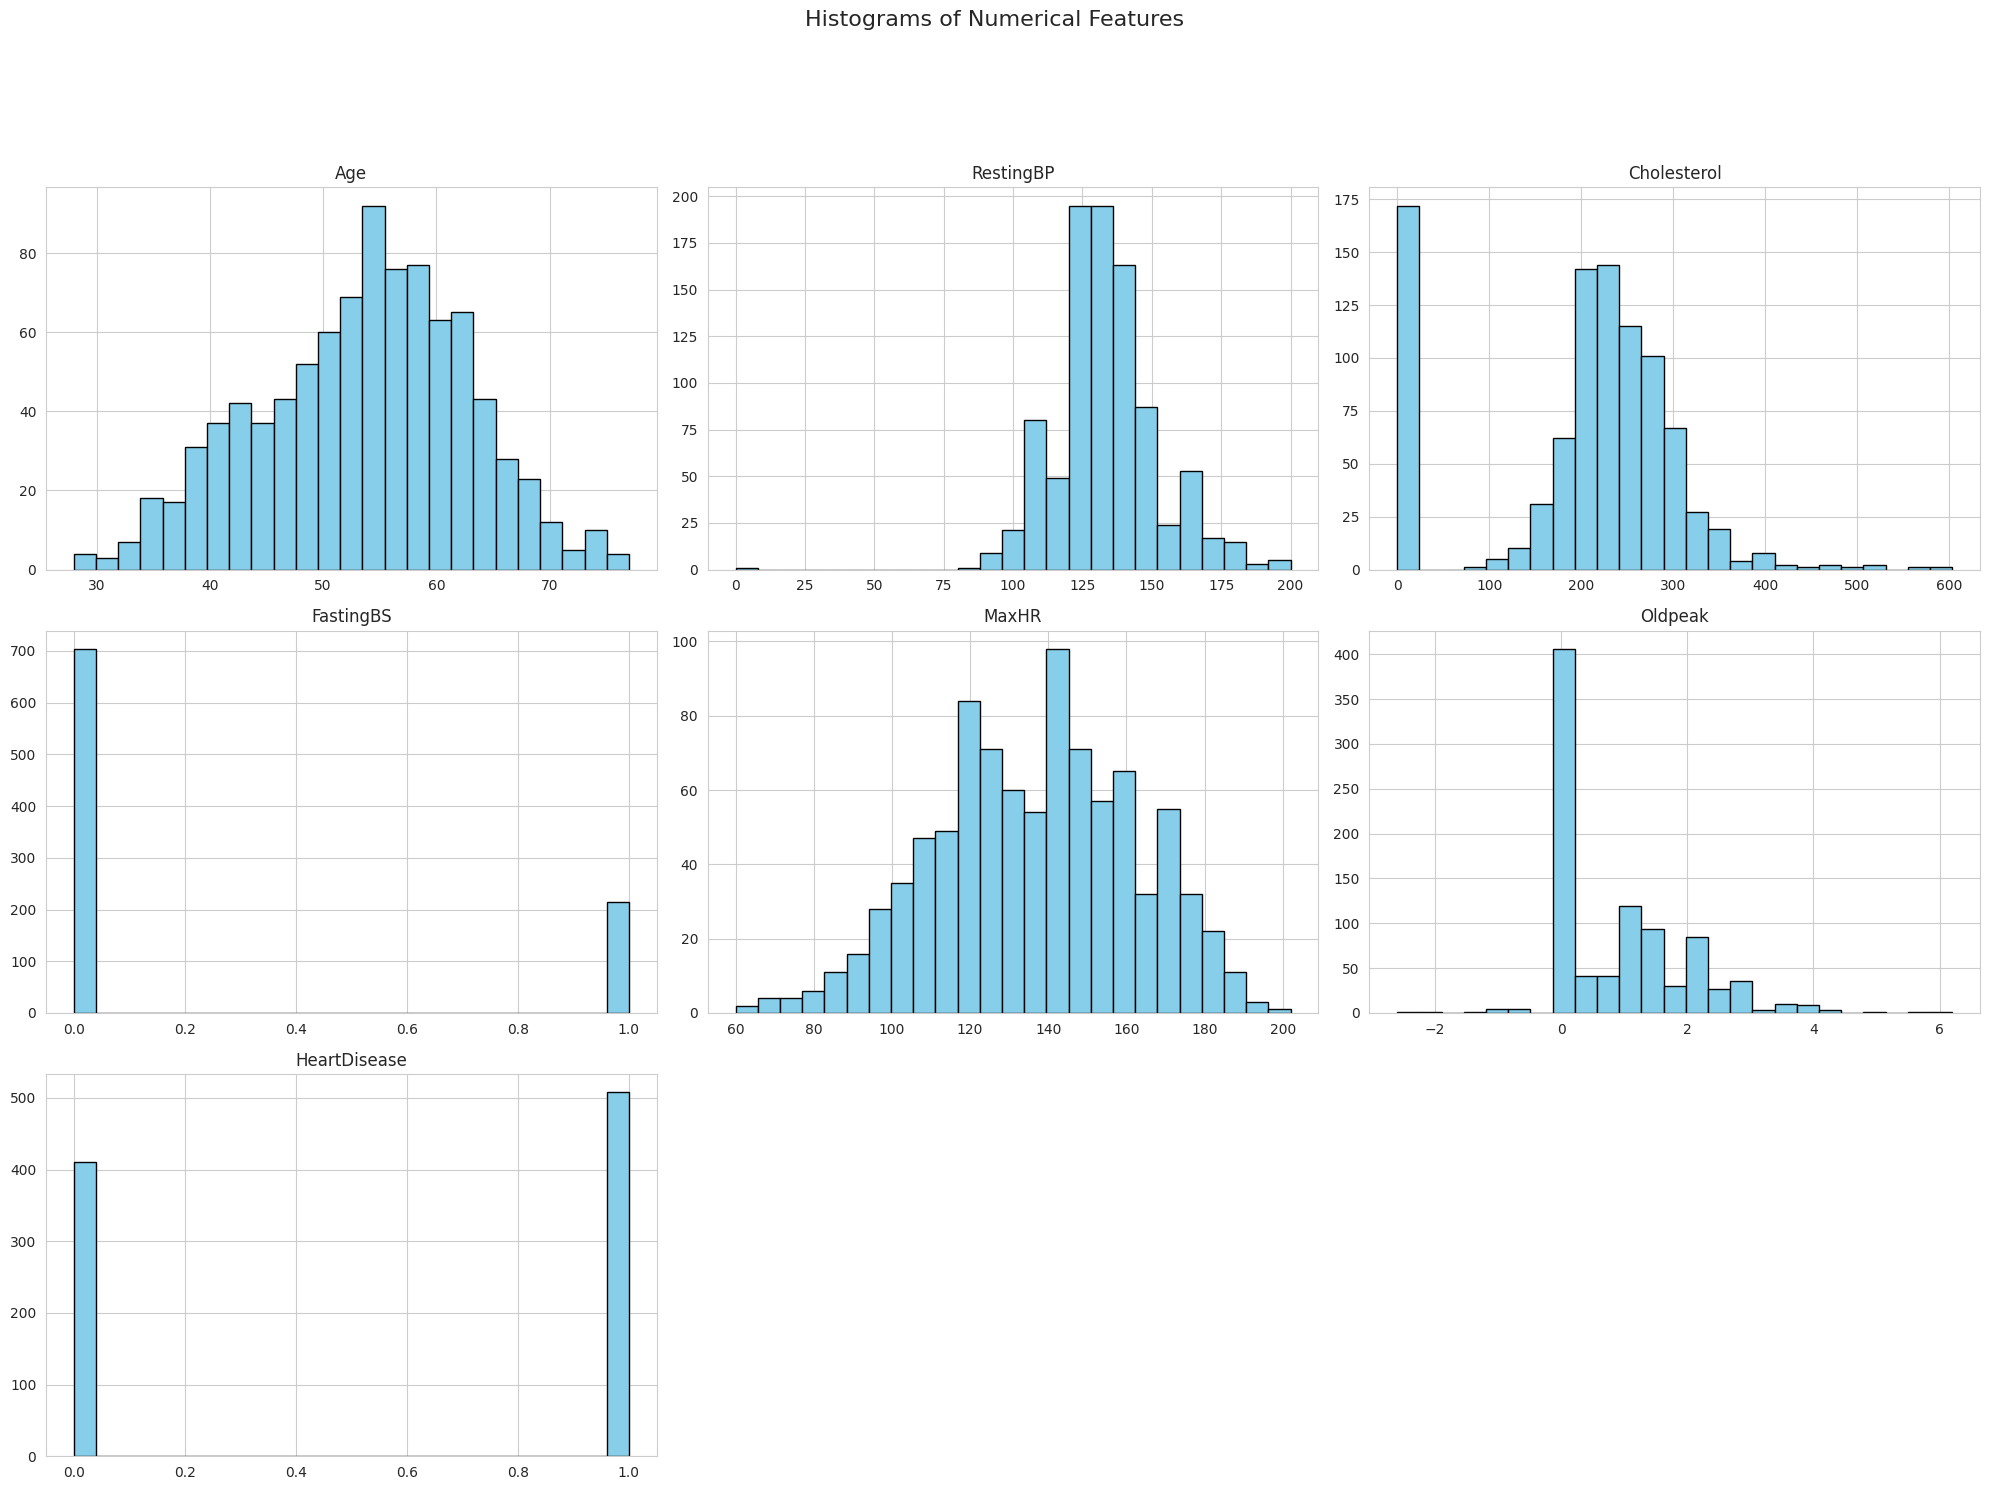

In [ ]:
# Select numrical columns
numrical_cols = hrt.select_dtypes(include= nmp.number).columns.tolist()
# Remve thee target colmn if its in thee numrical list
if 'target' in numrical_cols:
    numrical_cols.remove('target')

# Use a better style for plots
sbs.set_style("whitegrid")


# Adjust figsize for better readability
hrt[numrical_cols].hist(figsize=(20, 15), bins=25, color='skyblue', edgecolor='black')
# Include a main title
matplt.suptitle('Histograms of numrical Features', y=1.02, fontsize=16)
# Modify layout to avoid tittle overlap
matplt.tight_layout(rect=[0, 0.03, 1, 0.95])
# Dsplay thee plott
matplt.show()

plottbox plots for numrical features

# *Box Plots of numrical Features*

<Figure size 2000x1500 with 0 Axes>

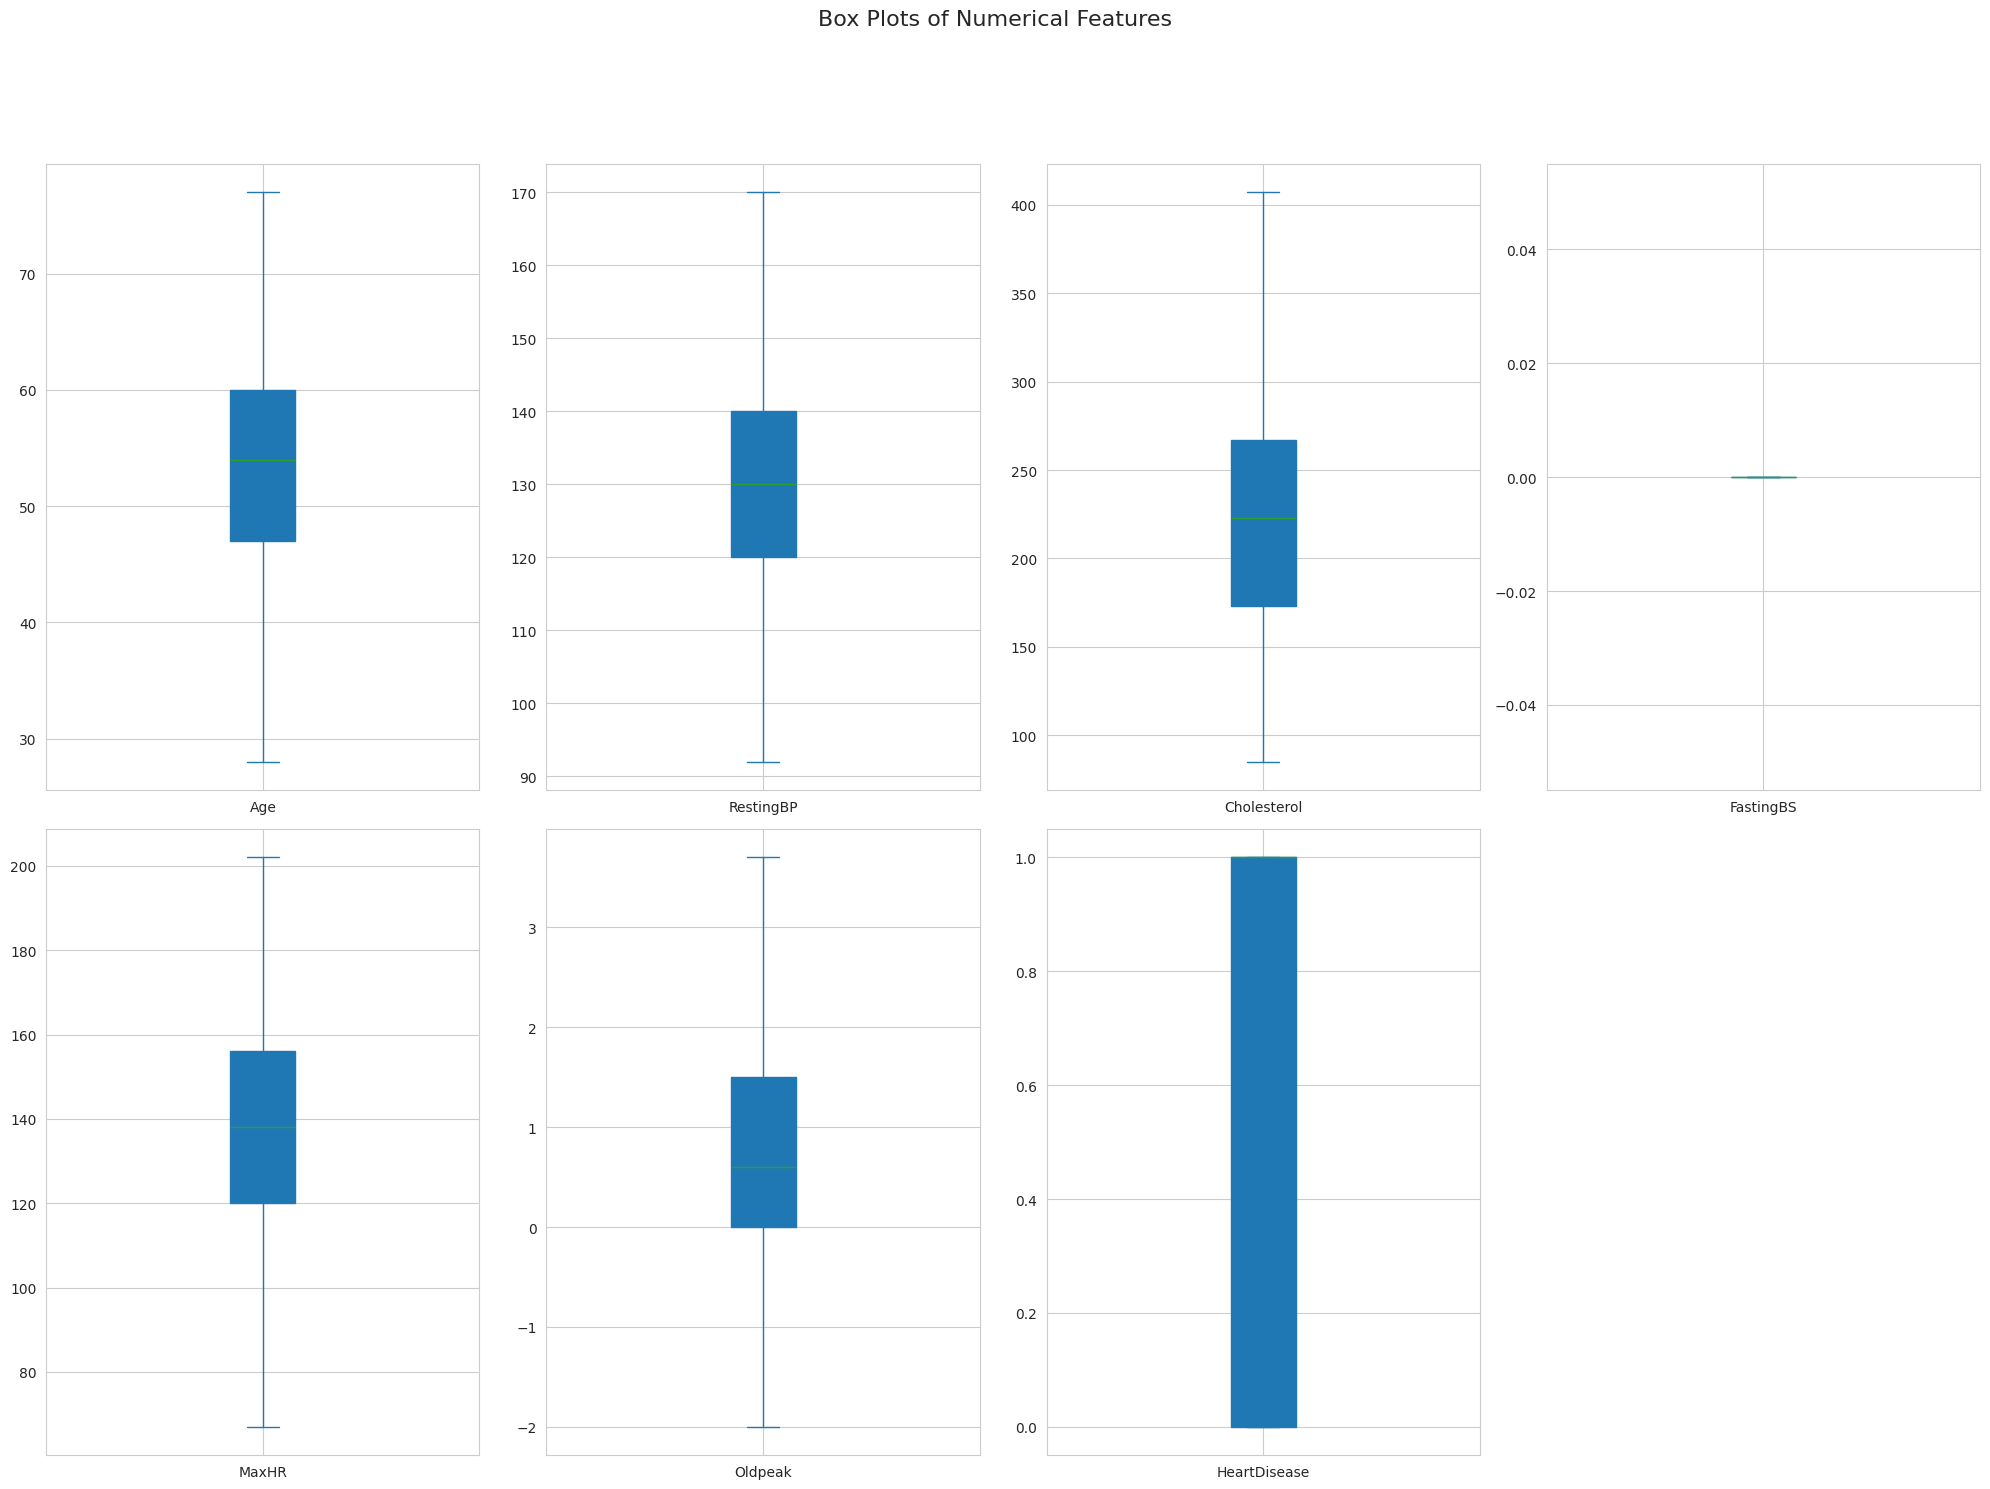

In [ ]:
# Make thee plots large and clear by setting thee overall figure size.
matplt.figure(figsize=(20, 15))
# Colour thee boxes and conceal thee outlier points for cleaner visuals.
hrt[numrical_cols].plot(kind='box', subplots=True, layout=(int(len(numrical_cols)/4) + 1, 4), figsize=(20,15), patch_artist=True, showfliers=False)
# Add a main tittle above thee plots with some spacing and a larger font size.
matplt.suptitle('Box Plots of numrical Features', y=1.02, fontsize=16)
# Modify thee subplottlayout to avoid overlapping elements and make space for thee title.
matplt.tight_layout(rect=[0, 0.03, 1, 0.95])
# Shw thee finished box plots on thee screen.
matplt.show()


# *Correlation Matrix of numrical Features*

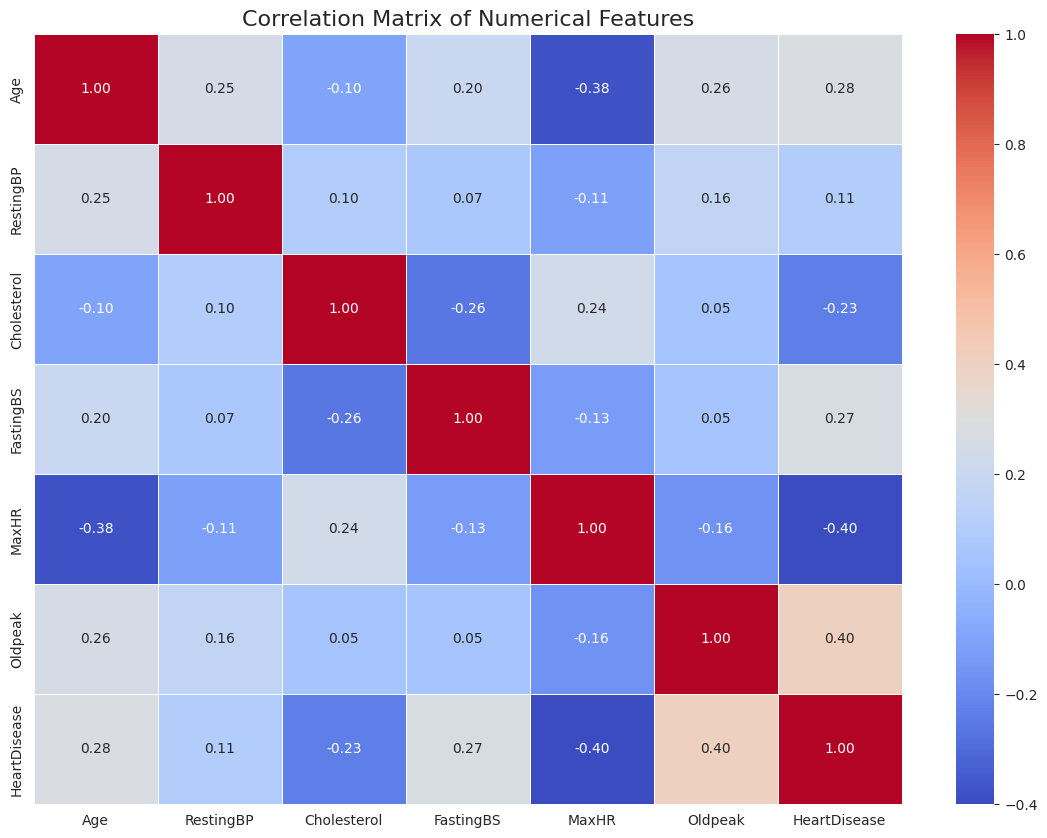

In [ ]:
# Determine each numrical feature's correlation coefficient.
corr_matrix = hrt[numrical_cols].corr()

# In order to better display thee heatmap, create a figure with greater size.
 matplt.figure(figsize=(14, 10)) # Adjust figsize for a larger heatmap

# Create a heatmap that displays correlation values with clear grid lines, two decimals formatted, annotations, and a colour gradient.
 sbs.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewihrths=.5) # Add linewihrths for separation

# Above thee heatmap, provide a tittle that is more decriptive and has a larger letter size.
 matplt.title('Correlation Matrix of numrical Features', fontsize=16) # Adjust tittle font size

# Display thee visualisation of thee heatmap on thee screen.
 matplt.show()

# *Scatter plottof Cholesterol vs Age colored by HeartDisease*

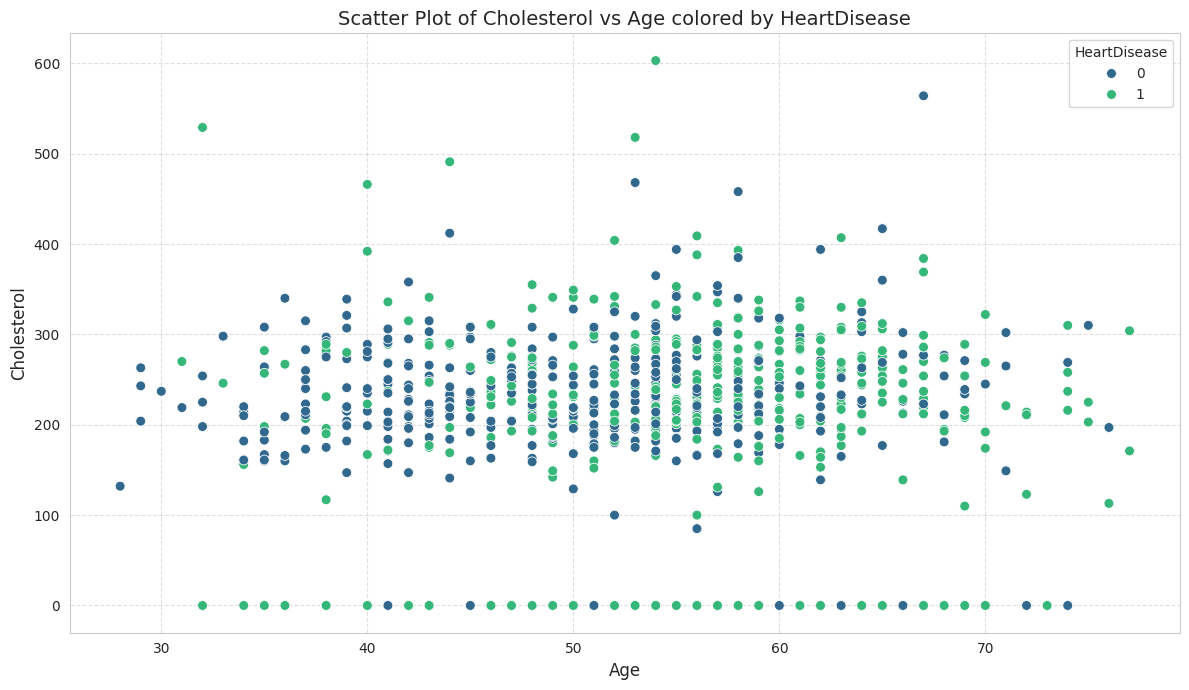

In [ ]:
# Choose every colmn in thee dtt that has a numeric deta type.
numrical_cols = hrt.select_hrtypes(include= nmp.number).columns.tolist()
# Iff thee trget colmn is present in thee list of numrical features, remove it.
if 'target' in numrical_cols:
    numrical_cols.remove('target')

# Specify which feature will be pltted on thee x-axis.
x_variable = 'Age'
# Specify which feature will be pltted on thee y-axis.
y_variable = 'Cholesterol'
# Specify which category variable is used to colour thee plot's points.
color_variable = 'HeartDisease'

# Adjust thee plotting area's size for improved visibility.
 matplt.figure(figsize=(12, 7))
# Using a certain colour scheme and marker size, make a scatter plottwith points coloured by thee categorical variable.
 sbs.scatterplot(data=hrt, x=x_variable, y=y_variable, hue=color_variable, palette='viridis', s=50)
# Include a tittle that describes thee variables and enlarges thee font size.
 matplt.title(f'Scatter plottof {y_variable} vs {x_variable} colored by {color_variable}', fontsize=14)
# Indicate thee x-axis using a larger text size.
 matplt.xlabel(x_variable, fontsize=12)
# Indicate thee y-axis using a larger text size.
 matplt.ylabel(y_variable, fontsize=12)
# Make grid lines partially transparent and dashed for easier reading.
 matplt.grid(True, linestyle='--', alpha=0.6)
# Put thee name of thee categorical variable in a legend and arrange it as best as possible.
 matplt.legend(title=color_variable, loc='best')
# Adapt thee layout automatically to prevent overlaps
 matplt.tight_layout()
# Show thee scatter plot.
 matplt.show()

# *volin plot*

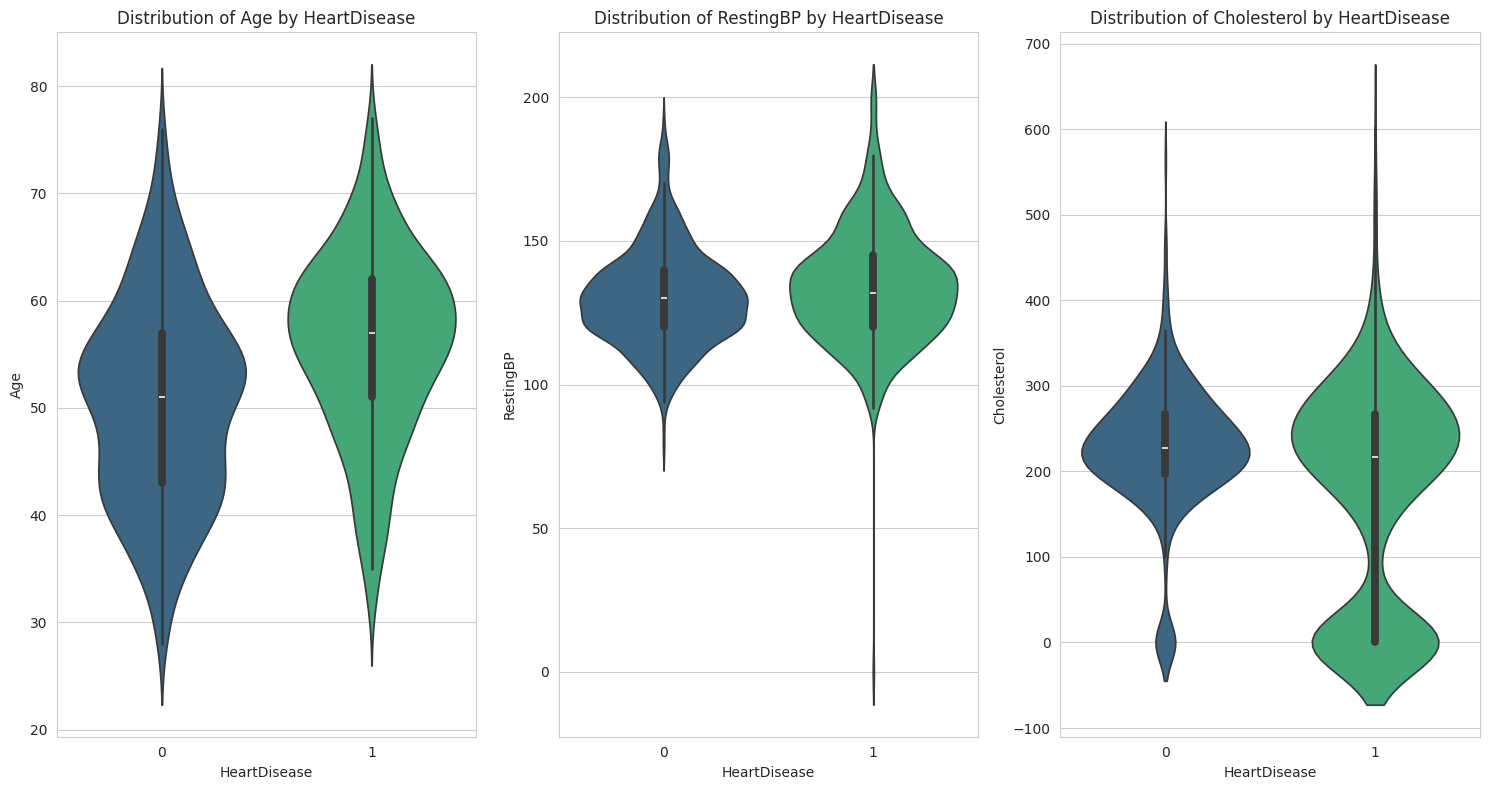

In [ ]:
# Specify a set of numrical characteristics to be displayed.
numrical_features = ['Age', 'RestingBP', 'Cholesterol'] # Make sure numrical_features is defined

# Define thee plots' overall figure size.
matplt.figure(figsize=(15, 8))
# To produce distinct subplots, loop over each numrcal fature.
for i, col in enumerate(numrical_features):
    # Make a subplottfor thee current feature in a grid with one row and three columns.
     matplt.subplot(1, 3, i + 1)
    # Create a violin plottwith clour cding and no legnd to dsplay thee distribution f thee features classified by HeartDisease categories.
    # Explicitly set hue='Obesity' to use palette for coloring by Obesity categories
     sbs.violi nmplot(x='HeartDisease', y=col, data=hrt, hue='HeartDisease', palette='viridis', legend=False)
    # Include a tittle with a reasonable font size that shows thee feature distribution by HeartDisease.
     matplt.title(f'Distribution of {col} by HeartDisease', fontsize=12)
    # Use a lower font size and label thee x-axis HeartDisease.
     matplt.xlabel('HeartDisease', fontsize=10)
    # Indicate thee name and font size of thee current feature on thee y-axis.
     matplt.ylabel(col, fontsize=10)
# Modify thee arrangement to avoid labels and subplots overlapping.
matplt.tight_layout()
# Show every violin plot.
matplt.show()

# **deta Pre-processing**

# Defining Variables

In [ ]:
# Choose every colmn as an i nmput feature, excluding thee target variable.
X = hrt_label_encoded.drop('HeartDisease', axis=1)

# To make a prediction, pick thee target variable column.
y = hrt_label_encoded['HeartDisease']


# Balancing

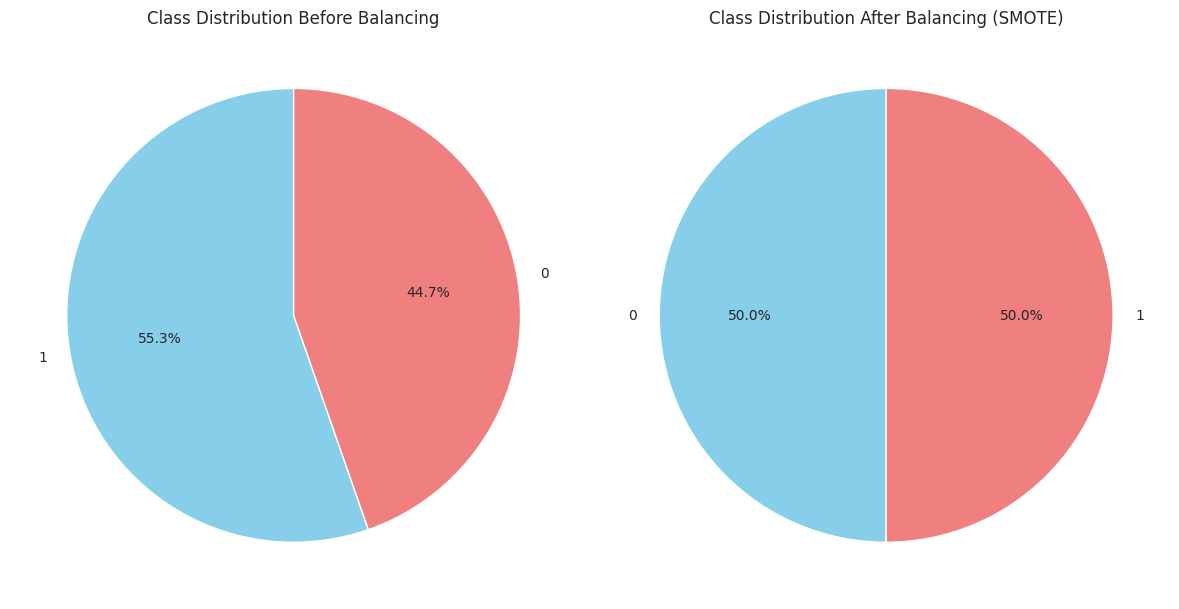

Shape of original features: (918, 11)
Shape of balanced features: (1016, 11)
Distribution of original target variable:
HeartDisease
1    508
0    410
Name: count, dtype: int64
Distribution of balanced target variable:
HeartDisease
0    508
1    508
Name: count, dtype: int64


In [ ]:
# To ensure reproducibility, start SMOTE with a fxed rndom seed.
smote = SMOTE(random_state=42)
# obalance thee dtt classes, create synthtic smples.
X_resampld, y_resampld = smote.fit_resample(X, y)

# For side-by-side plots, set up a figg of a certain sze.
matplt.figure(figsize=(12, 6))
# Before balancing, create thee first subplottto display thee class distribution.
matplt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
# Create a pie chart showing thee original class distribution using custom colours and percentage labels.
y.value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'], labels=y.value_counts().index)
# Before balancing, add a tittle that reflects thee class distribution.
matplt.title('Class Distribution Before Balancing')
# For a neater appearance, remove thee default y-axis label.
matplt.ylabel('') #

# After balancing, create thee second subplottto display thee class distribution.
matplt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
# Crate a pie chart with cstom colours and % labels showing thee resampld class distribution.
y_resampld.value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'], labels=y_resampld.value_counts().index)
# After using SMOTE, add a tittle that shows thee distribution of classes.
matplt.title('Class Distribution After Balancing (SMOTE)')
# For consistency, hide thee default y-axis label once again.
matplt.ylabel('') # Hide thee default y-label

# Modify thee arrangement to avoid plottand tittle overlap.
matplt.tight_layout() # Adjust layout to prevent overlapping
# Shw thee pie charts next to each other.
matplt.show()

# Before balancing, output thee original feature set's shape.
print("Shape of original features:", X.shape)
# After using SMOTE, output thee feature set's shape.
print("Shape of balanced features:", X_resampld.shape)
# Output thee number of classes in thee first trget varible.
print("Distribution of original target variable:")
print(y.value_counts())
# Output each class's number in thee balanced goal variable.
print("Distribution of balanced target variable:")
print(y_resampld.value_counts())

# Handling Outliers

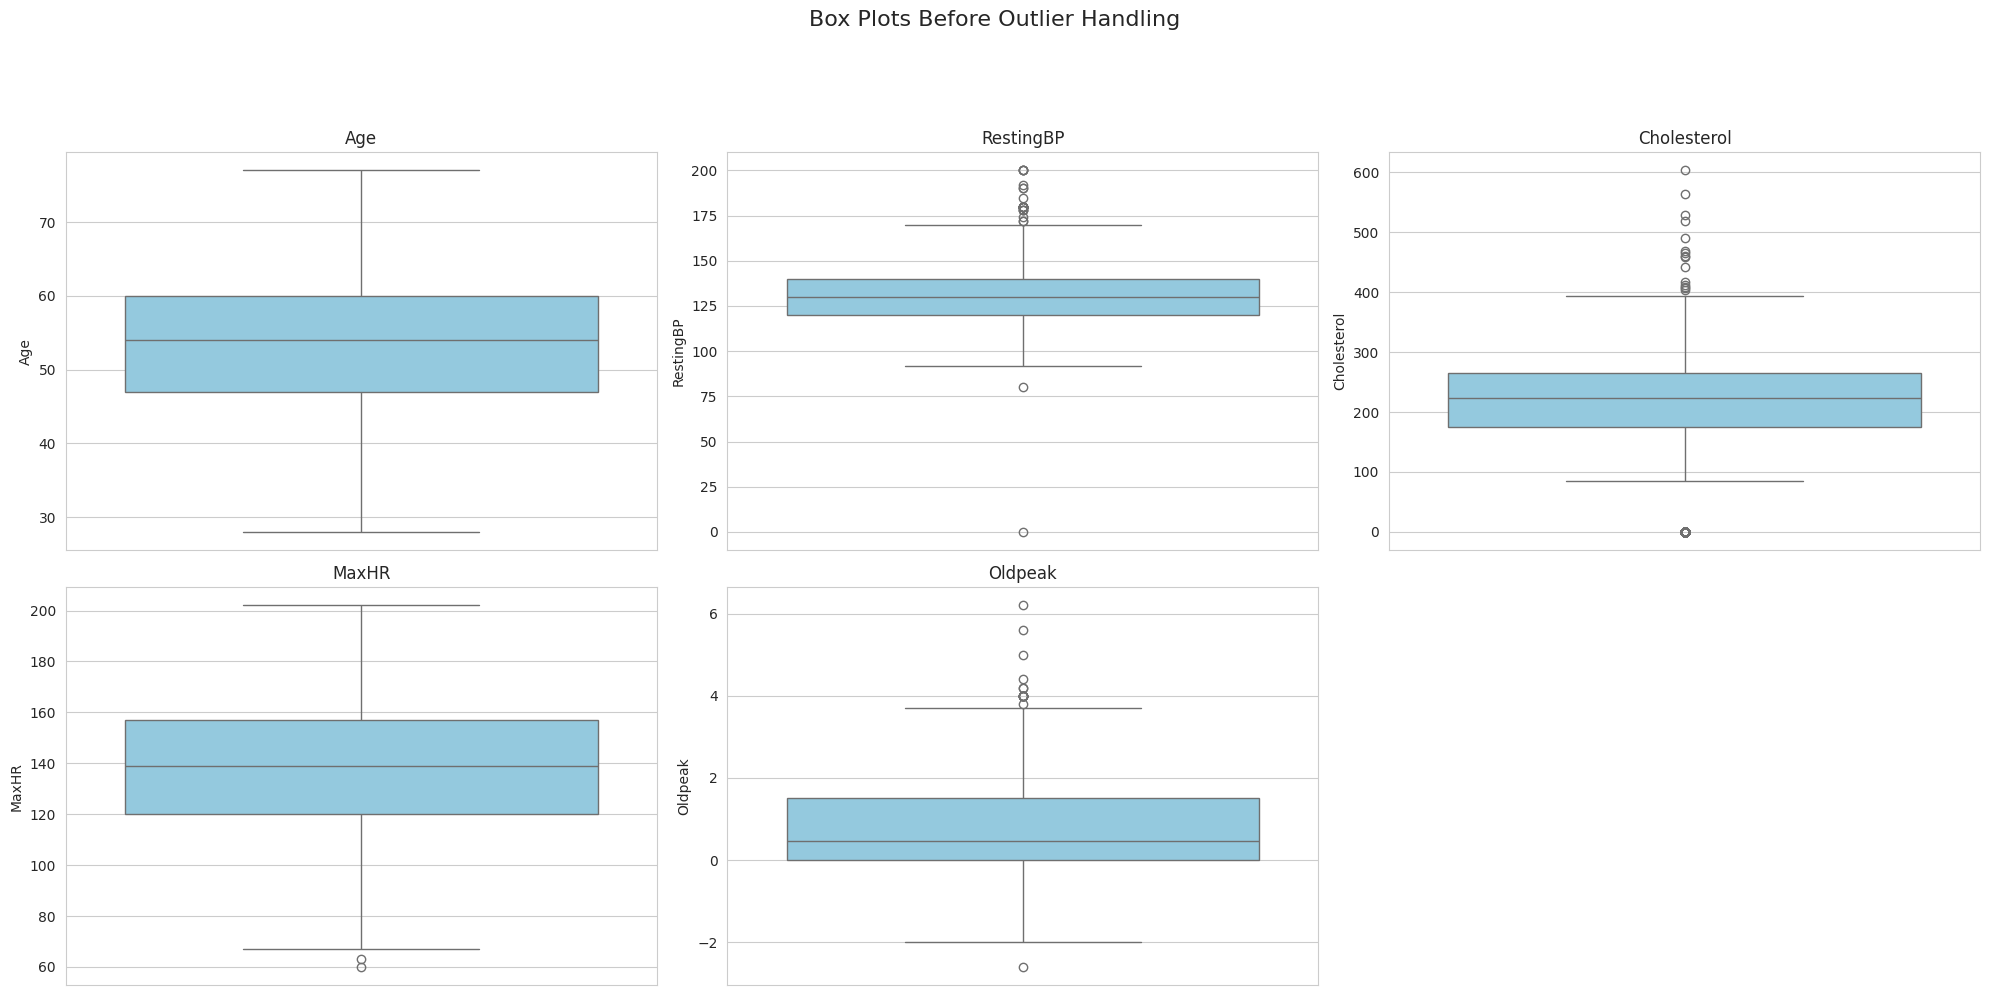

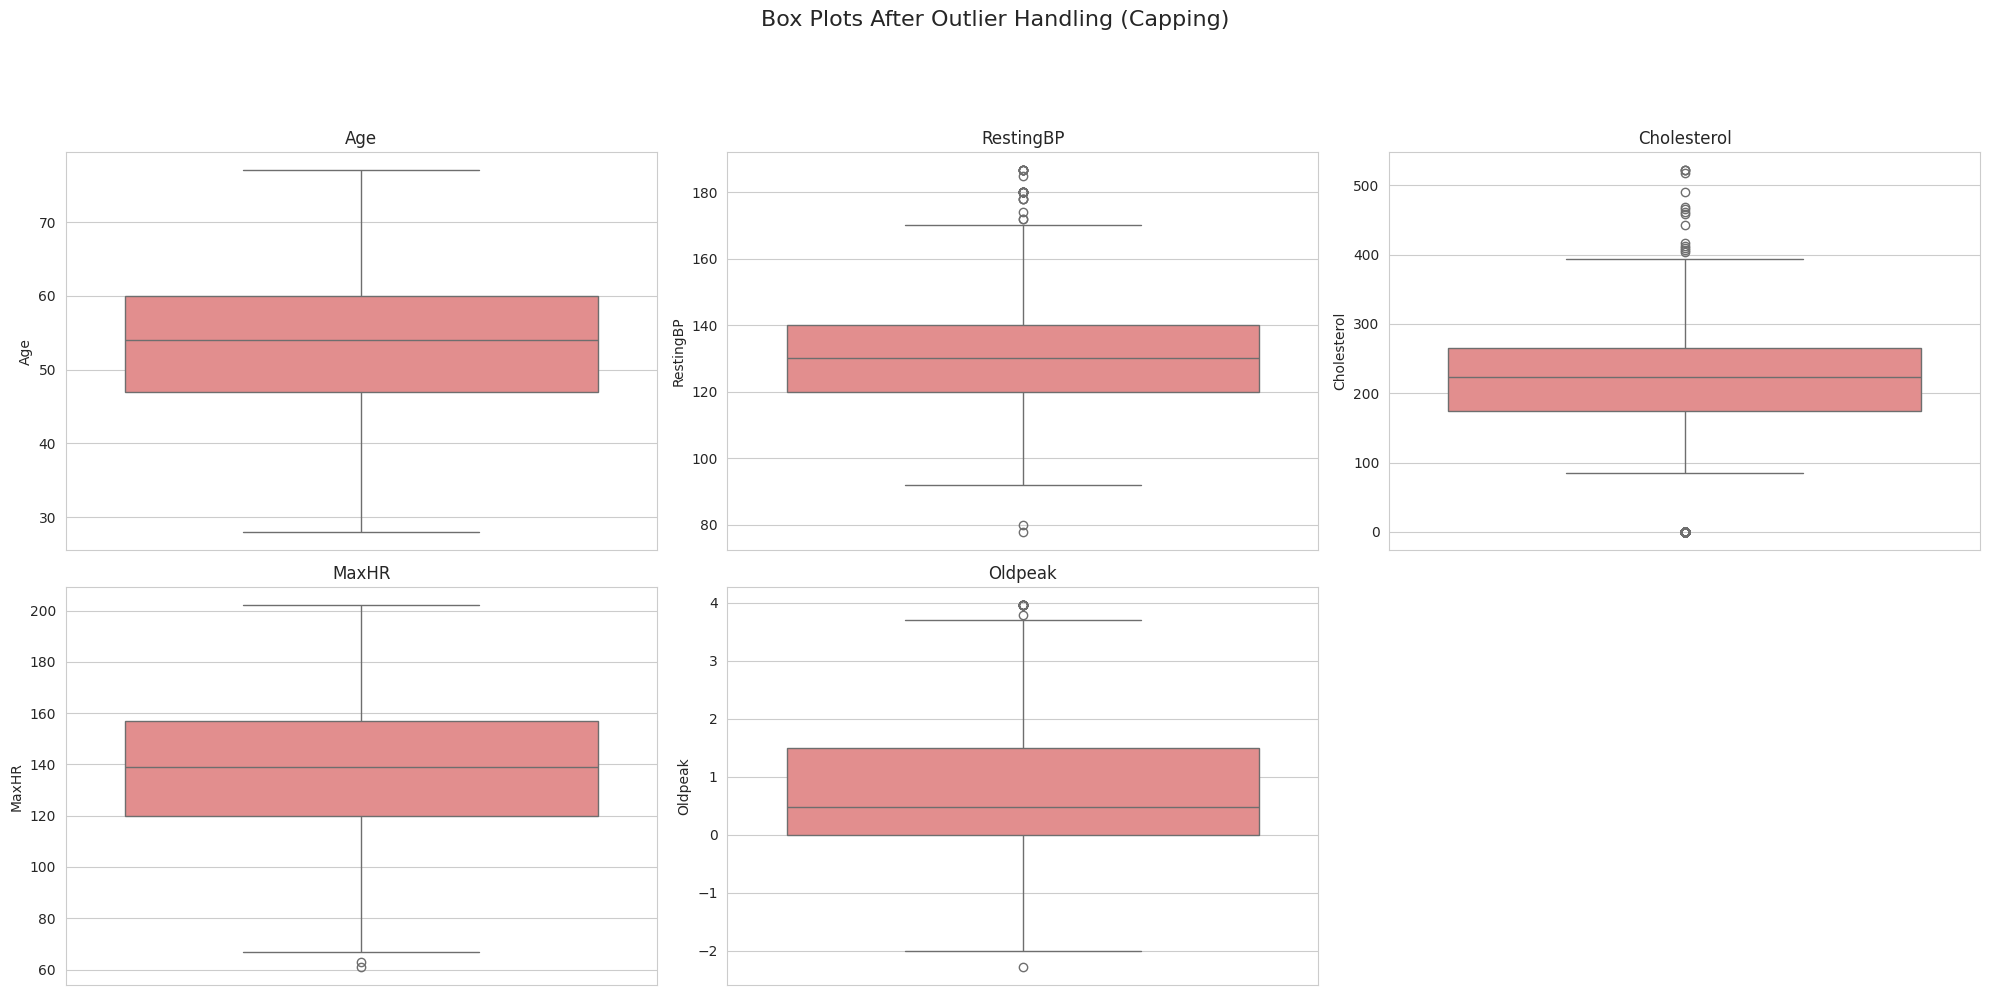

Outliers handled in specified numerical columns using capping.


In [ ]:
# Create a list of numrical columns and modify it as necessary to look for outliers.
numrical_cols_for_outliers = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak'] # Add or remove columns as needed

# Prior to outlier treatment, make a huge figure for box plots.
matplt.figure(figsize=(20, 10)) # Adjust figsize

# Above thee box plots, include a primary tittle with more space and a larger font size.
matplt.suptitle('Box Plots Before Outlier Handling', y=1.02, fontsize=16)
# To produce distinct box plots, loop over each numrical column.
for i, col in enumerate(numrical_cols_for_outliers):
    # Before charting, make sure thee current colmn is present in thee resampld dataset.
    if col in X_resampld.columns:
        # To accommodate all plots, arrange subplots in two rows with an adequate number of columns.
        matplt.subplot(2, int(len(numrical_cols_for_outliers)/2) + 1, i + 1) # Arrange subplots
        # Before capping, create box plots that display thee distribution with outliers included.
        # Use X_resampld here as it contains thee deta after balancing and before capping
        sbs.boxplot(y=X_resampld[col], color='skyblue', showfliers=True) # Show outliers before capping
        # Include thee colmn name in thee tittle of each subplot.
        matplt.title(col, fontsize=12)
# Modify thee subplottarrangement to avoid overlap and make room for thee main headline.
matplt.tight_layout(rect=[0, 0.03, 1, 0.95])
# Before treating outliers, show thee data's box plots.
matplt.show()

# To use utliercapping, make a duplicate of thee resampld dataset.
X_balanced_capped = X_resampld.copy()

# Apply outlier capping by looping over thee numrical columns.
for col in numrical_cols_for_outliers:
    # Before processing, make sure thee colmn is present in thee copied dataset.
    if col in X_balanced_capped.columns:
        # Determine thee current column's mean.
        mean = X_balanced_capped[col].mean()
        # Determine thee current column's standard deviation.
        std = X_balanced_capped[col].std()
        # Calculate thee mean minus three times thee standard deviation as thee lower criterion for capping.
        lower_limit = mean - 3 * std
        # Use thee mean plus three times thee standard deviation to get thee upper threshold for capping.
        upper_limit = mean + 3 * std

        # Substitute thee lower threshold value for numbers that fall below it.
        X_balanced_capped[col] =  nmp.where(X_balanced_capped[col] < lower_limit, lower_limit, X_balanced_capped[col])
        # Substitute thee upper threshold value for values that exceed it.
        X_balanced_capped[col] =  nmp.where(X_balanced_capped[col] > upper_limit, upper_limit, X_balanced_capped[col])
    else:
        # Indicate whether thee given colmn is absent from thee dataset.
        print(f"Warning: colmn '{col}' not found in thee DataFrame.")


# Construct a sizable figure for box plotting following outlier treatment.
matplt.figure(figsize=(20, 10)) # Adjust figsize
# Include a primary tittle with font size and spacing above thee box plots for thee capped data.
matplt.suptitle('Box Plots After Outlier Handling (Capping)', y=1.02, fontsize=16)
# After capping, loop over each number colmn to produce separate box plots.
for i, col in enumerate(numrical_cols_for_outliers):
    # Before plotting, make sure thee colmn is present in thee capped dataset.
    if col in X_balanced_capped.columns: # Use thee capped detafrme for thee after plot
        # Set up subplots in a manner consistent with thee prior plots.
         matplt.subplot(2, int(len(numrical_cols_for_outliers)/2) + 1, i + 1) # Arrange subplots
        # plottbox plots with varying colours that display thee distribution with outliers after capping
         sbs.boxplot(y=X_balanced_capped[col], color='lightcoral', showfliers=True) # Show outliers after capping
        # Include thee colmn name in thee tittle of each subplot.
         matplt.title(col, fontsize=12)
# Modify thee subplottarrangement to avoid overlap and make room for thee main headline.
matplt.tight_layout(rect=[0, 0.03, 1, 0.95])
# Shw every violin plott.
matplt.show()

print("Outliers handled in specified numrical columns using capping.")


# Scaling

In [ ]:
# Set up a scaler that uses thee median and interquartile range to lessen thee impact of outliers.
robust_scaler = RobustScaler()

# Apply thee transformation after fitting thee scaler to thee resampld feature data.
X_rescaled = robust_scaler.fit_transform(X_resampld)

# spliting

In [ ]:
# Use an 80-20 ratio to divide thee rescaled deta into traning and tsting sets, maintaining thee class distribution and repeatability of thee random seed in each set.
X_train, X_test, y_train, y_test = train_test_split(X_rescaled, y_resampld, test_size=0.2, random_state=42, stratify=y_resampld)

# **mdlApplication and Evaluation**

In [ ]:
# Modify thee evalte_classfiction_mdl function to return metrics
def evalte_classfiction_mdl(y_true, y_pred, y_prob, model_name="Model", dataset_type="Set"):
  """
  Calculates and prints common classification evaluation metrics,
  including thee deta iled classification report.

  Args:
    y_true: True labels.
    y_pred: Predicted labels.
    y_prob: Predicted probabilities for thee positive class.
    model_name: thee name of thee mdlbeing evaluated.
    dataset_type: thee type of dtt (e.g., "traning Set", "Test Set").

  Returns:
    A dictionary containing thee calculated metrics.
  """
  print(f"\n--- Evaluating {model_name} on {dataset_type} ---")

  # deta iled Classification Report
  print("\ndeta iled Classification Report:")
  print(classification_report(y_true, y_pred))

  # Overll Metrics
  print("Overall Metrics:")

  # Accracy
  accuracy = accuracy_score(y_true, y_pred)
  print(f"Accuracy: {accuracy:.4f}")

  # Precison (Weighted)
  precision_weighted = precision_score(y_true, y_pred, average='weighted')
  print(f"Precision (Weighted): {precision_weighted:.4f}")

  # Recll (Weighted)
  recall_weighted = recall_score(y_true, y_pred, average='weighted')
  print(f"Recall (Weighted): {recall_weighted:.4f}")

  # Fone Scre (Weighted)
  f1_weighted = f1_score(y_true, y_pred, average='weighted')
  print(f"F1 Score (Weighted): {f1_weighted:.4f}")

  # Specificty (Tre Negative Rate)
  cm = confusion_matrix(y_true, y_pred)
  if cm.shape == (2, 2):
      TN, FP, FN, TP = cm.ravel()
      specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
      print(f"Specificity: {specificity:.4f}")
  else:
      specificity = None # Or 0 depending on how you want to handle this case
      print("Specificity: N/A (Confusion matrix is not 2x2, likely due to single class predictions)")


  # Brer Scre
  brier = brier_score_loss(y_true, y_prob)
  print(f"Brier Score: {brier:.4f}")

  # Matthws Correltion Coeficient (MCC)
  mcc = matthews_corrcoef(y_true, y_pred)
  print(f"MCC: {mcc:.4f}")
  print("-------------------------------------------------\n")
  return {
      'accuracy': accuracy,
      'precision_weighted': precision_weighted,
      'recall_weighted': recall_weighted,
      'f1_weighted': f1_weighted,
      'specificity': specificity,
      'brier_score_loss': brier,
      'mcc': mcc
  }


In [ ]:
def plott_conf_matrx(y_true, y_pred, title="Confusion Matrix", cmap="Blues"):
  """
  Generates and plots a confusion matrix.

  Args:
    y_true: True labels.
    y_pred: Predicted labels.
    title: tittle for thee confusion matrix plot.
    cmap: Colormap for thee heatmap.
  """
  cm = confusion_matrix(y_true, y_pred)
  matplt.figure(figsize=(6, 4))
  sbs.heatmap(cm, annot=True, fmt="d", cmap=cmap,
              xticklabels=sorted(list(set(y_true).union(set(y_pred)))),
              yticklabels=sorted(list(set(y_true).union(set(y_pred)))))
  matplt.title(title)
  matplt.xlabel("Predicted")
  matplt.ylabel("Actual")
  matplt.show()


In [ ]:
def plott_rc_cuve(y_true, y_prob, title="ROC Curve"):
  """
  Generates and plots an ROC curve and calculates thee AUC.

  Args:
    y_true: True binary labels (0 or 1).
    y_prob: Predicted probabilities for thee positive class.
    title: tittle for thee ROC curve plot.

  Returns:
      thee AUC value.
  """
  fpr, tpr, thresholds = roc_curve(y_true, y_prob)
  roc_auc = auc(fpr, tpr)

  matplt.figure(figsize=(8, 6))
  matplt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  matplt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # plottthee random guess line
  matplt.xlim([0.0, 1.0])
  matplt.ylim([0.0, 1.05])
  matplt.xlabel('False Positive Rate')
  matplt.ylabel('True Positive Rate')
  matplt.title(title)
  matplt.legend(loc="lower right")
  matplt.grid(True)
  matplt.show()

  print(f"{title} AUC: {roc_auc:.4f}")
  return roc_auc # Return thee AUC value


# Support vector classifier (SVC)

traning set

In [ ]:
# Set up thee Support Vector Classifier with a fixed random seed, an RBF kernel, and probability estimates enabled.
model_svc = SVC(random_state=42, kernel='rbf', C=1.0, gamma='scale', probability=True)
# Use thee traning deta to fit thee model.
model_svc.fit(X_train, y_train)
# Mke prdictions about thee traning data's class labels
y_pred_svc_train = model_svc.predict(X_train)
# Estimate thee traning data's class probabilities in order to compute metrcs
y_prob_svc_train = model_svc.predict_proba(X_train)[:, 1]
 # For evaluation, use thee likelihood of thee positive class (class 1).

# Print a headline stating that an evaluation of traning is being conducted.
print("SVC Classifier (traning Set Evaluation)")
evalte_classfiction_mdl(y_train, y_pred_svc_train, y_prob_svc_train, model_name="Model", dataset_type="Set")

SVC Classifier (Training Set Evaluation)

--- Evaluating Model on Set ---

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       406
           1       0.90      0.91      0.91       406

    accuracy                           0.91       812
   macro avg       0.91      0.91      0.91       812
weighted avg       0.91      0.91      0.91       812

Overall Metrics:
Accuracy: 0.9052
Precision (Weighted): 0.9052
Recall (Weighted): 0.9052
F1 Score (Weighted): 0.9052
Specificity: 0.9039
Brier Score: 0.0741
MCC: 0.8103
-------------------------------------------------



{'accuracy': 0.9051724137931034,
 'precision_weighted': 0.9051748718415386,
 'recall_weighted': 0.9051724137931034,
 'f1_weighted': 0.9051722699717749,
 'specificity': np.float64(0.9039408866995073),
 'brier_score_loss': np.float64(0.07410772501401423),
 'mcc': np.float64(0.810347285630914)}

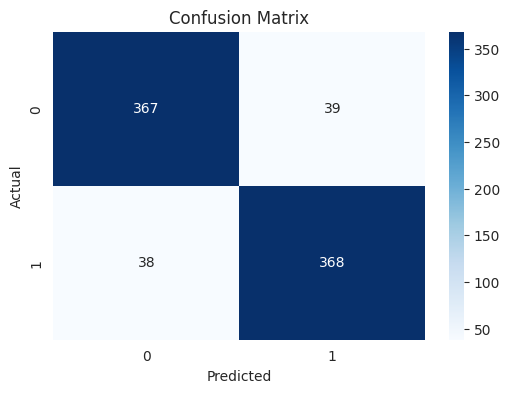

In [ ]:
plott_conf_matrx(y_train, y_pred_svc_train, title="Confusion Matrix", cmap="Blues")

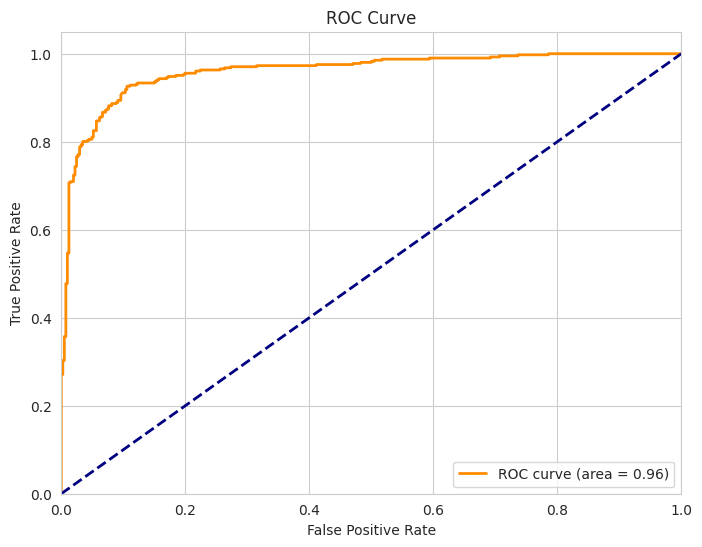

ROC Curve AUC: 0.9598


np.float64(0.9598449367856536)

In [ ]:
plott_rc_cuve(y_train, y_prob_svc_train, title="ROC Curve")

test set

In [ ]:
# Use thee test deta to predict class labels.
y_pred_svc_test = model_svc.predict(X_test)
# Obtain thee test data's anticipated probbilities for thee postive class.
y_prob_svc_test = model_svc.predict_proba(X_test)[:, 1] # Probability of thee positive class (class 1)

# Print thee header for thee test set performance classification report.
print("SVC Classifier (Test Set Evaluation)")
evalte_classfiction_mdl(y_test, y_pred_svc_test, y_prob_svc_test, model_name="Model", dataset_type="Set")

SVC Classifier (Test Set Evaluation)

--- Evaluating Model on Set ---

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       102
           1       0.91      0.86      0.88       102

    accuracy                           0.89       204
   macro avg       0.89      0.89      0.89       204
weighted avg       0.89      0.89      0.89       204

Overall Metrics:
Accuracy: 0.8873
Precision (Weighted): 0.8882
Recall (Weighted): 0.8873
F1 Score (Weighted): 0.8872
Specificity: 0.9118
Brier Score: 0.0955
MCC: 0.7754
-------------------------------------------------



{'accuracy': 0.8872549019607843,
 'precision_weighted': 0.8881876866750169,
 'recall_weighted': 0.8872549019607843,
 'f1_weighted': 0.8871871318314059,
 'specificity': np.float64(0.9117647058823529),
 'brier_score_loss': np.float64(0.09552465293907075),
 'mcc': np.float64(0.7754420276093302)}

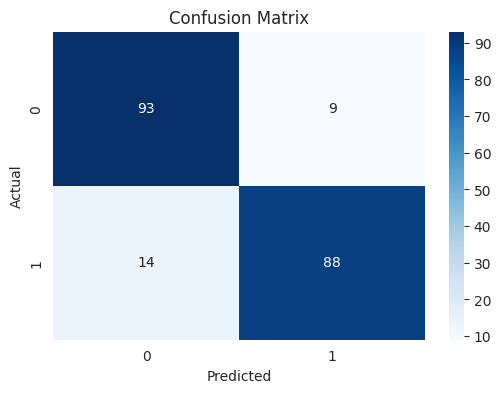

In [ ]:
plott_conf_matrx(y_test, y_pred_svc_test, title="Confusion Matrix", cmap="Blues")

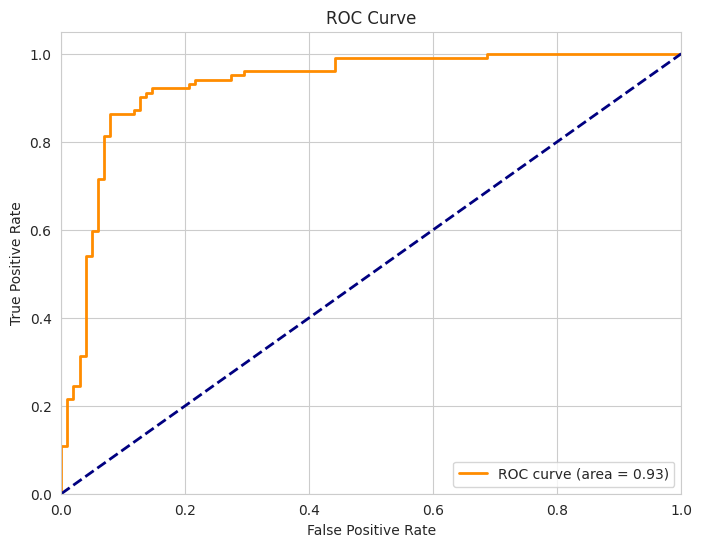

ROC Curve AUC: 0.9300


np.float64(0.9300269127258747)

In [ ]:
plott_rc_cuve(y_test, y_prob_svc_test, title="ROC Curve")

# Gradient Boosting Classifier

train set

In [ ]:

# (Ensure that you include: import GradientBoostingClassifier from sklearn.ensemble.)


# Start thee Gradient Boosting Classifier with a few estimators and a random state; you can adjust it later.
model_gb = GradientBoostingClassifier(random_state=40,n_estimators=6 )

# Train thee mdlon thee traning data
model_gb.fit(X_train, y_train)

# Generate predictions on thee traning st
y_pred_gb_train = model_gb.predict(X_train)
# Get predicted probabilities for thee traning set (needed for Brier Score and ROC AUC)
y_prob_gb_train = model_gb.predict_proba(X_train)[:, 1] # Probability of thee positive class (class 1)

# Print thee classification report for thee traning set
print("Gradient Boosting Classifier (traning Set Evaluation)")
evalte_classfiction_mdl(y_train, y_pred_gb_train, y_prob_gb_train, model_name="Model", dataset_type="Set")

Gradient Boosting Classifier (Training Set Evaluation)

--- Evaluating Model on Set ---

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86       406
           1       0.86      0.87      0.87       406

    accuracy                           0.87       812
   macro avg       0.87      0.87      0.87       812
weighted avg       0.87      0.87      0.87       812

Overall Metrics:
Accuracy: 0.8658
Precision (Weighted): 0.8658
Recall (Weighted): 0.8658
F1 Score (Weighted): 0.8658
Specificity: 0.8596
Brier Score: 0.1467
MCC: 0.7316
-------------------------------------------------



{'accuracy': 0.8657635467980296,
 'precision_weighted': 0.8658190290696617,
 'recall_weighted': 0.8657635467980296,
 'f1_weighted': 0.8657584568319736,
 'specificity': np.float64(0.8596059113300493),
 'brier_score_loss': np.float64(0.14670343254604284),
 'mcc': np.float64(0.7315825737638395)}

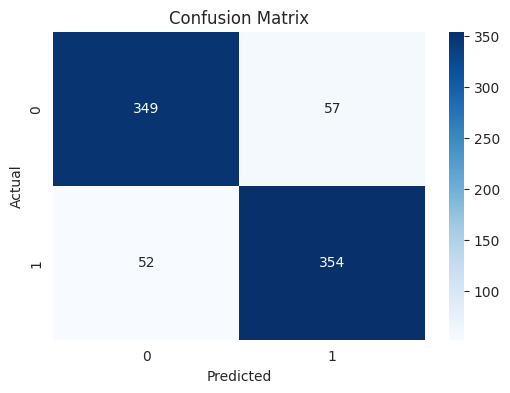

In [ ]:
plott_conf_matrx(y_train, y_pred_gb_train, title="Confusion Matrix", cmap="Blues")

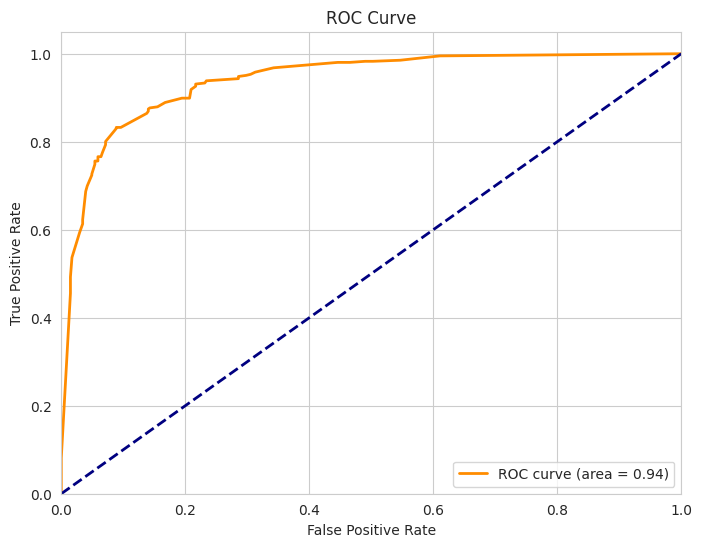

ROC Curve AUC: 0.9390


np.float64(0.9389514426460239)

In [ ]:
plott_rc_cuve(y_train, y_prob_gb_train, title="ROC Curve")

test set

In [ ]:
# Use thee traned Gradint Bosting modl to prodce predctions on thee tst st.
y_pred_gb_test = model_gb.predict(X_test)
# Obtain thee test set's estimated probabilties for thee pos class (class 1).
y_prob_gb_test = model_gb.predict_proba(X_test)[:, 1] # Probability of thee positive class (class 1)

# Print thee classification report with thee test data's precision, recall, f1-score, and other metrics.
print("Gradient Boosting Classifier (Test Set Evaluation)")
evalte_classfiction_mdl(y_test, y_pred_gb_test, y_prob_gb_test, model_name="Model", dataset_type="Set")

Gradient Boosting Classifier (Test Set Evaluation)

--- Evaluating Model on Set ---

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       102
           1       0.88      0.84      0.86       102

    accuracy                           0.86       204
   macro avg       0.86      0.86      0.86       204
weighted avg       0.86      0.86      0.86       204

Overall Metrics:
Accuracy: 0.8627
Precision (Weighted): 0.8633
Recall (Weighted): 0.8627
F1 Score (Weighted): 0.8627
Specificity: 0.8824
Brier Score: 0.1516
MCC: 0.7260
-------------------------------------------------



{'accuracy': 0.8627450980392157,
 'precision_weighted': 0.8633038120908741,
 'recall_weighted': 0.8627450980392157,
 'f1_weighted': 0.8626923076923078,
 'specificity': np.float64(0.8823529411764706),
 'brier_score_loss': np.float64(0.15158250008403903),
 'mcc': np.float64(0.7260486951573563)}

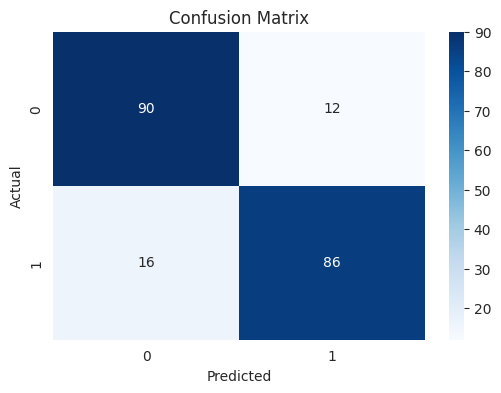

In [ ]:
plott_conf_matrx(y_test, y_pred_gb_test, title="Confusion Matrix", cmap="Blues")

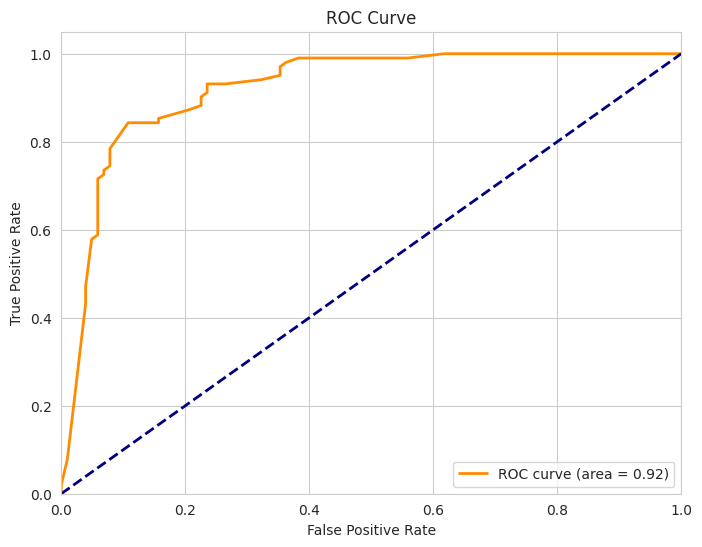

ROC Curve AUC: 0.9216


np.float64(0.9216166858900423)

In [ ]:
plott_rc_cuve(y_test, y_prob_gb_test, title="ROC Curve")

# LightGBM (LGBM)

train set

In [ ]:
# Construct a LightGBM dtt object using labels and traning features.
lgb_train = lgb.Dataset(X_train, y_train)

# Establish thee LightGBM traning settings (needs adjusting, example placeholders).
# Define parameters for LightGBM traning
# These are example parameters; you may need to tune them
params = {
    'objective': 'binary',  # For binary classification
    'metric': 'binary_logloss', # Evaluation metric
    'boosting_type': 'gbdt', # Traditional Gradient Boosting Decision Tree - Changed from 'gbhrt' to 'gbdt'
    'num_leaves': 31, # Maximum number of leaves in one tree
    'learning_rate': 0.05, # Step size shrinkage
    'feature_fraction': 0.9, # Fraction of features for each iteration
    'bagging_fraction': 0.8, # Fraction of deta for each iteration
    'bagging_freq': 5, # Frequency for bagging
    'verbose': -1, # Suppress verbose output during traning
    'seed': 42 # Random seed for reproducibility
}


# Use thee given parameters and boosting rounds to train thee LightGBM model.
# num_boost_round is thee number of boosting iterations (analogous to n_estimators)
model_lgbm = lgb.train(params, lgb_train, num_boost_round=10)
y_prob_lgbm_train = model_lgbm.predict(X_train)

# Use thee trained mdlto forecast traning set probabilities.
# Generate predictions on thee traning set
# For classification, predict() returns probabilities for objective='binary' by default
y_pred_lgbm_train = model_lgbm.predict(X_train)
# Use a 0.5 threshold to translate predcted probablities int bnary clas lbels.
y_pred_lgbm_train_classes = (y_pred_lgbm_train > 0.5).astype(int)

# Print thee classification report with thee anticipated classes and actual traning labels.
# Print thee classification report for thee traning set
print("LightGBM Classifier (traning Set Evaluation)")
# Pass thee predicted probabilities for evaluation metrics like Brier Score and ROC AUC
evalte_classfiction_mdl(y_train, y_pred_lgbm_train_classes, y_pred_lgbm_train, model_name="Model", dataset_type="Set")

LightGBM Classifier (Training Set Evaluation)

--- Evaluating Model on Set ---

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       406
           1       0.86      0.88      0.87       406

    accuracy                           0.87       812
   macro avg       0.87      0.87      0.87       812
weighted avg       0.87      0.87      0.87       812

Overall Metrics:
Accuracy: 0.8695
Precision (Weighted): 0.8697
Recall (Weighted): 0.8695
F1 Score (Weighted): 0.8694
Specificity: 0.8571
Brier Score: 0.1537
MCC: 0.7391
-------------------------------------------------



{'accuracy': 0.8694581280788177,
 'precision_weighted': 0.869682400932401,
 'recall_weighted': 0.8694581280788177,
 'f1_weighted': 0.869438326325306,
 'specificity': np.float64(0.8571428571428571),
 'brier_score_loss': np.float64(0.15366124149114246),
 'mcc': np.float64(0.7391404949863533)}

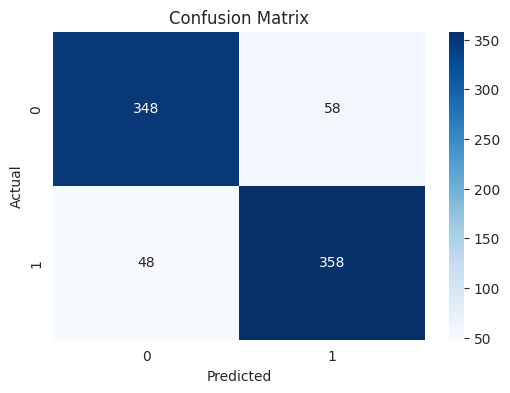

In [ ]:
plott_conf_matrx(y_train, y_pred_lgbm_train_classes, title="Confusion Matrix", cmap="Blues")

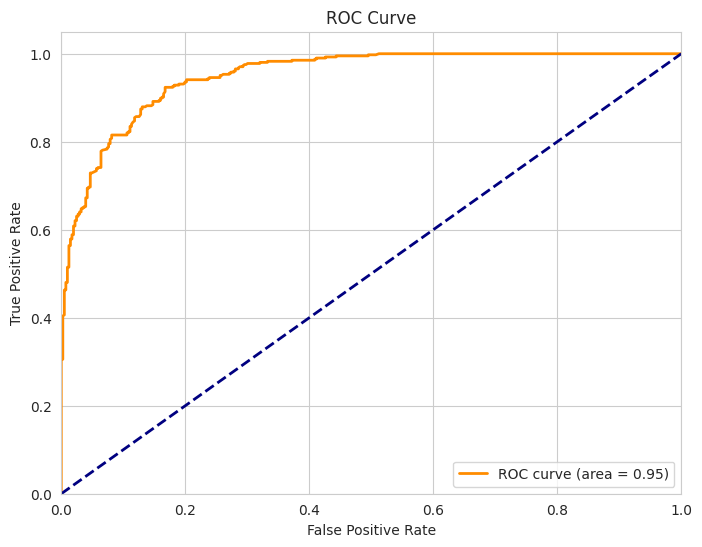

ROC Curve AUC: 0.9500


np.float64(0.9500048533087432)

In [ ]:
plott_rc_cuve(y_train, y_prob_lgbm_train, title="ROC Curve")

test set

In [ ]:
# Generate predictions on thee test set
# For classification, predict() returns probabilities for objective='binary' by default
# Use thee LightGBM mdlto generate projected probbilities for thee tst set.
y_pred_lgbm_test = model_lgbm.predict(X_test)
# Use 0.5 as thee threshold to translate these probabilities into binary class predictions.

y_pred_lgbm_test_classes = (y_pred_lgbm_test > 0.5).astype(int) # Convert probabilities to binary labels
y_prob_lgbm_test = model_lgbm.predict(X_test)
# Get predicted probabilities for thee test set (needed for Brier Score and ROC AUC)
# y_prob_lgbm_test is already thee probability of thee positive class from model_lgbm.predict(X_test)

# To assess performance on thee test set, print thee classification report.
print("LightGBM Classifier (Test Set Evaluation)")
evalte_classfiction_mdl(y_test, y_pred_lgbm_test_classes, y_pred_lgbm_test, model_name="Model", dataset_type="Set")

LightGBM Classifier (Test Set Evaluation)

--- Evaluating Model on Set ---

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       102
           1       0.84      0.81      0.83       102

    accuracy                           0.83       204
   macro avg       0.83      0.83      0.83       204
weighted avg       0.83      0.83      0.83       204

Overall Metrics:
Accuracy: 0.8284
Precision (Weighted): 0.8287
Recall (Weighted): 0.8284
F1 Score (Weighted): 0.8284
Specificity: 0.8431
Brier Score: 0.1639
MCC: 0.6571
-------------------------------------------------



{'accuracy': 0.8284313725490197,
 'precision_weighted': 0.8287157287157286,
 'recall_weighted': 0.8284313725490197,
 'f1_weighted': 0.8283942605811523,
 'specificity': np.float64(0.8431372549019608),
 'brier_score_loss': np.float64(0.16386880744987448),
 'mcc': np.float64(0.6571470397424246)}

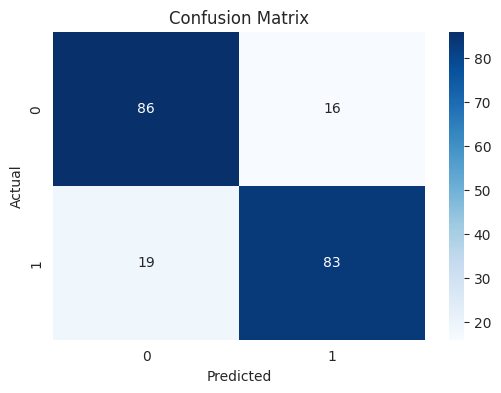

In [ ]:
plott_conf_matrx(y_test, y_pred_lgbm_test_classes, title="Confusion Matrix", cmap="Blues")

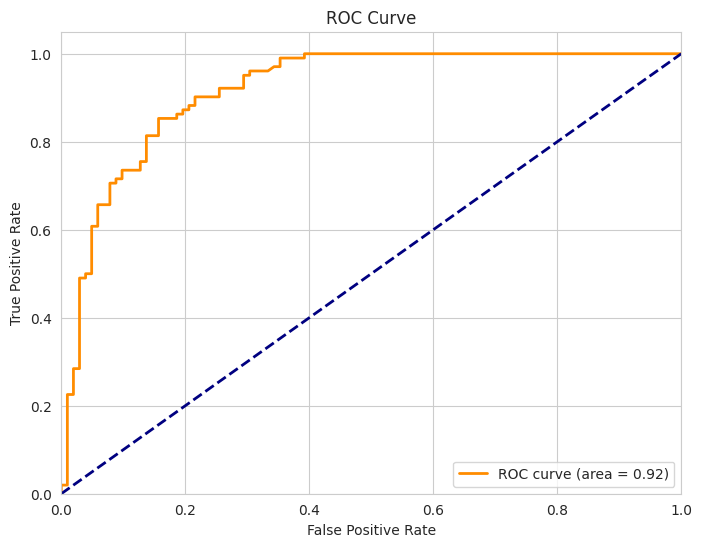

ROC Curve AUC: 0.9182


np.float64(0.9181564782775855)

In [ ]:
plott_rc_cuve(y_test, y_prob_lgbm_test, title="ROC Curve")

# mdlPerformance Metrics Comparison (Test Set)

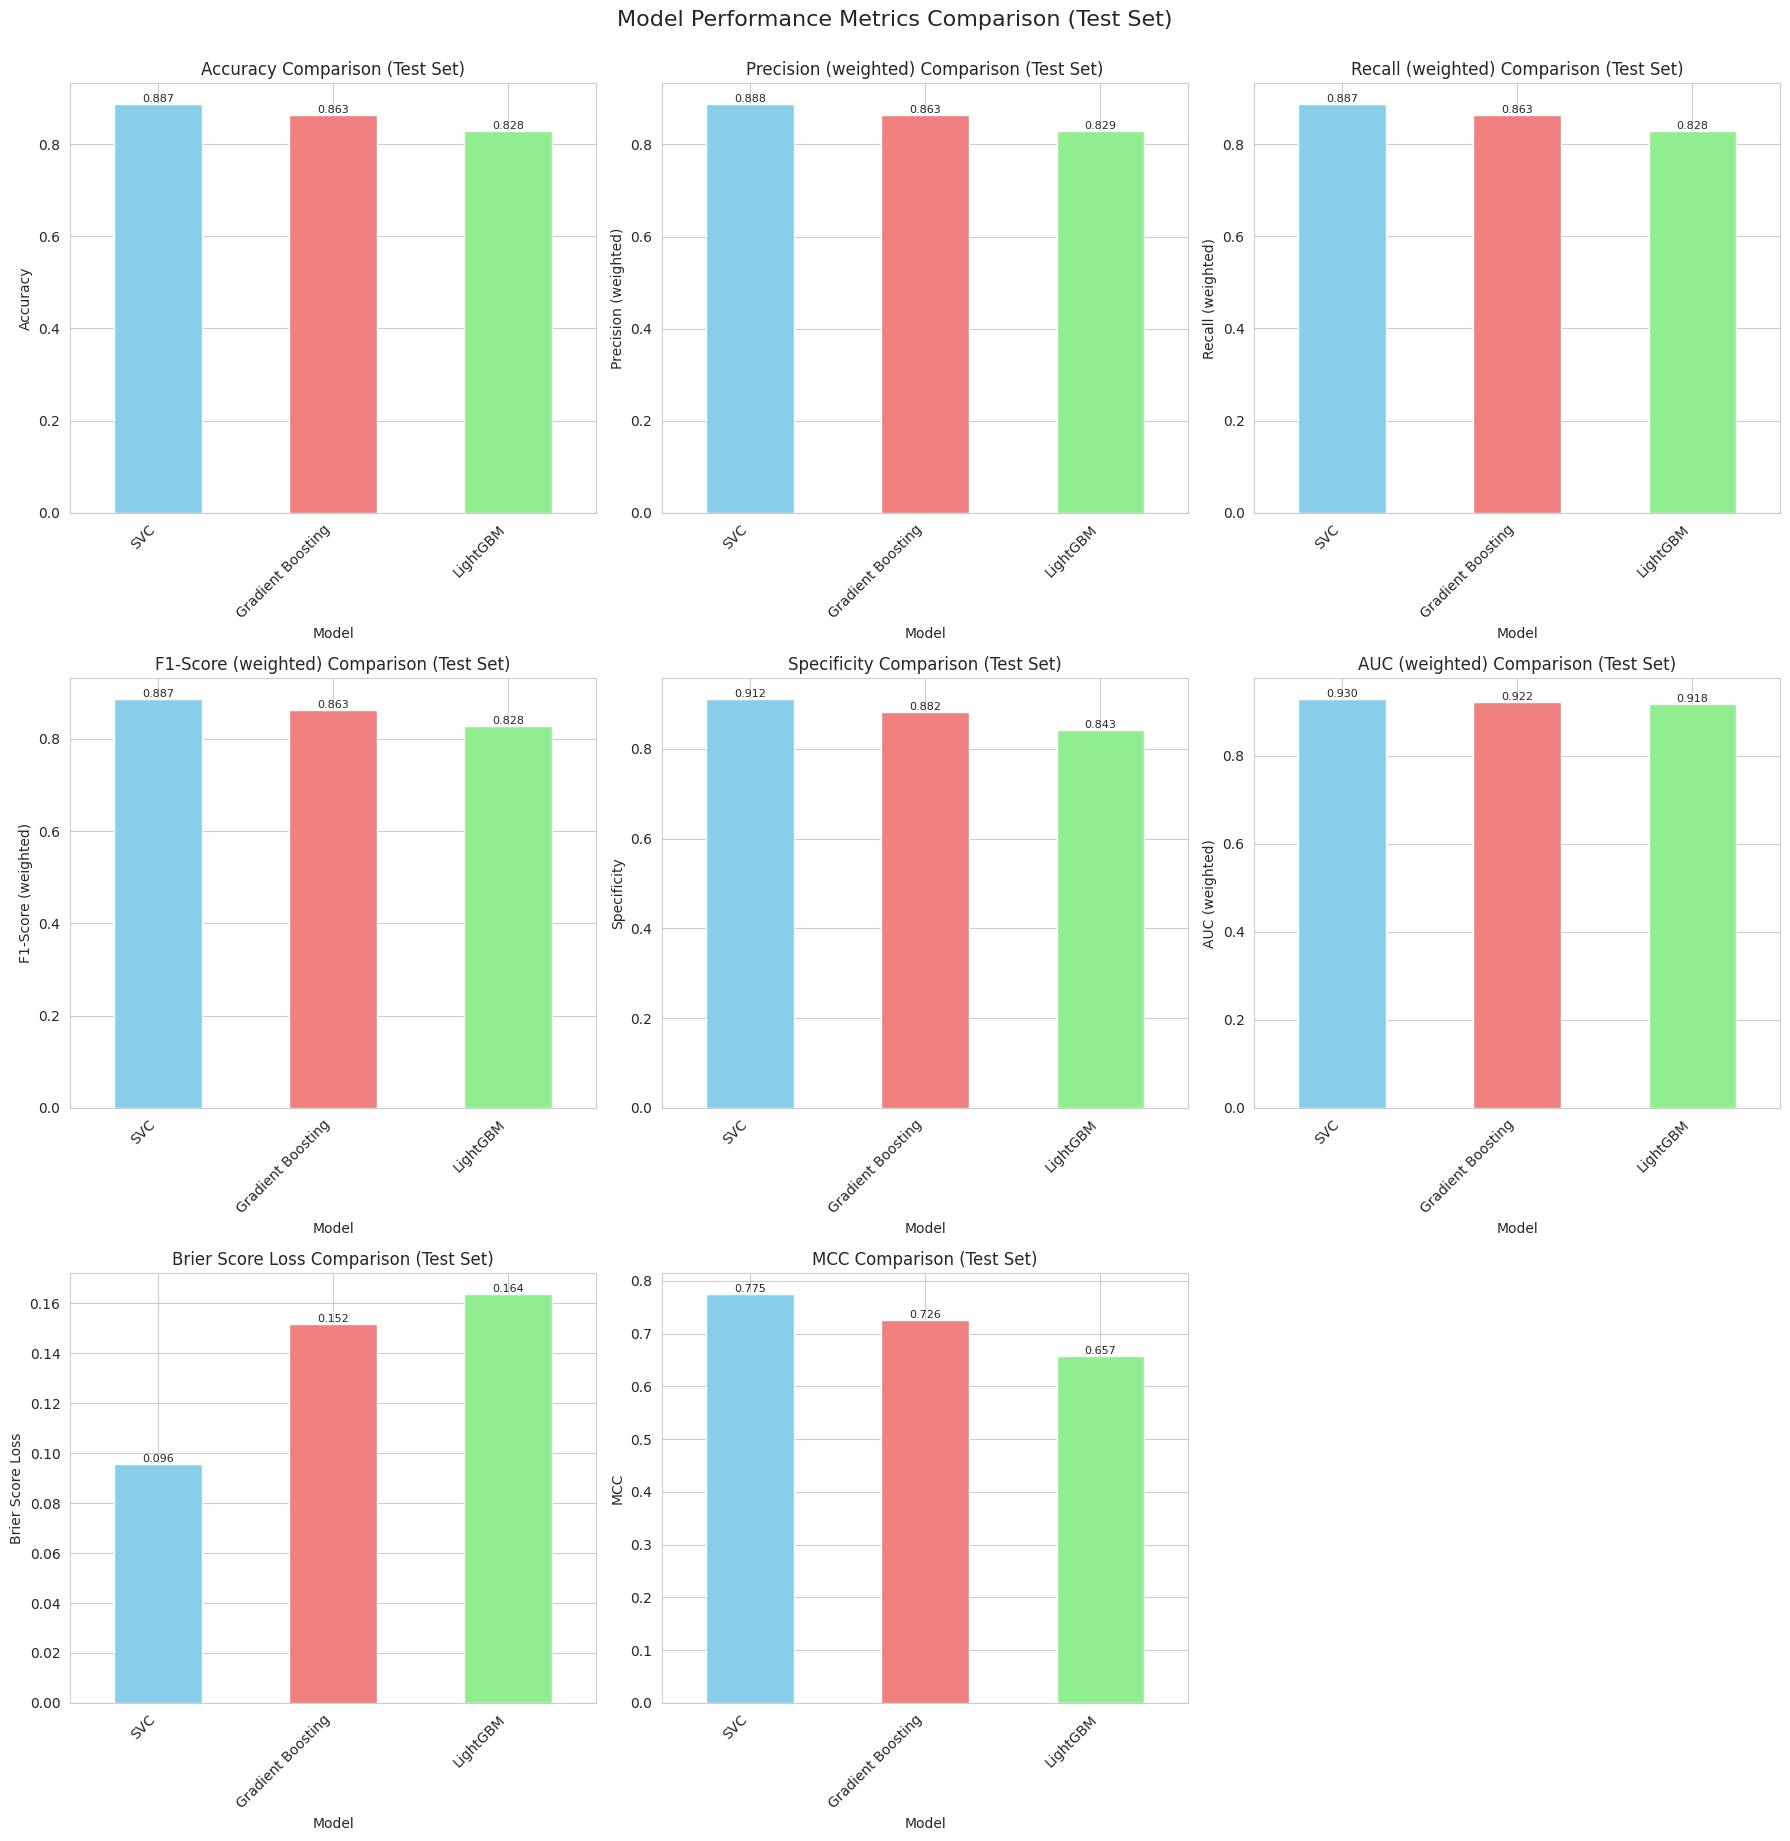

In [ ]:

# Extract individual metrics from thee dictionary
accuracy_svc_test = metrics_svc_test['accuracy']
precision_svc_test = metrics_svc_test['precision_weighted']
recall_svc_test = metrics_svc_test['recall_weighted']
f1_svc_test = metrics_svc_test['f1_weighted']
specificity_svc_test = metrics_svc_test['specificity']
brier_svc_test = metrics_svc_test['brier_score_loss']
mcc_svc_test = metrics_svc_test['mcc']



# Extract individual metrics from thee dictionary
accuracy_gb_test = metrics_gb_test['accuracy']
precision_gb_test = metrics_gb_test['precision_weighted']
recall_gb_test = metrics_gb_test['recall_weighted']
f1_gb_test = metrics_gb_test['f1_weighted']
specificity_gb_test = metrics_gb_test['specificity']
brier_gb_test = metrics_gb_test['brier_score_loss']
mcc_gb_test = metrics_gb_test['mcc']



# Extract individual metrics from thee dictionary
accuracy_lgbm_test = metrics_lgbm_test['accuracy']
precision_lgbm_test = metrics_lgbm_test['precision_weighted']
recall_lgbm_test = metrics_lgbm_test['recall_weighted']
f1_lgbm_test = metrics_lgbm_test['f1_weighted']
specificity_lgbm_test = metrics_lgbm_test['specificity']
brier_lgbm_test = metrics_lgbm_test['brier_score_loss']
mcc_lgbm_test = metrics_lgbm_test['mcc']


# --- mdlPerformance Metrics Comparison (Test Set) ---
# Create a dictioary to organise mdlnames and their corresponding metrics for easy comparison.
comparison_dict = {
    'Model': ['SVC', 'Gradient Boosting', 'LightGBM'],
    # Populate thee dictionary with thee metrics calculated for each mdlon thee test set.
    # Ensure thse variables are defined in thee preceding cells.
    'Accuracy': [accuracy_svc_test, accuracy_gb_test, accuracy_lgbm_test],
    'Precision (weighted)': [precision_svc_test, precision_gb_test, precision_lgbm_test],
    'Recall (weighted)': [recall_svc_test, recall_gb_test, recall_lgbm_test],
    'F1-Score (weighted)': [f1_svc_test, f1_gb_test, f1_lgbm_test],
    'Specificity': [specificity_svc_test, specificity_gb_test, specificity_lgbm_test],
    # Use thee calculated AUC values from thee ROC curve plots.
    'AUC (weighted)': [roc_auc_test_svc, roc_auc_test_gb, roc_auc_test_lgbm],
    'Brier Score Loss': [brier_svc_test, brier_gb_test, brier_lgbm_test],
    'MCC': [mcc_svc_test, mcc_gb_test, mcc_lgbm_test]
}

# Convert thee dictionary into a pandas detafrme and set thee mdlnames as thee index for better readability.
metrics_df = pds.DataFrame(comparison_dict).set_index('Model')
# Convert all metric columns to numeric values to ensure proper plotting and calculations
metrics_df_numeric = metrics_df.apply(pds.to_numeric, errors='coerce')

# define a dictionary mapping mdlnames to specific colours for consistent visualisation;
model_colors = {
    'SVC': 'skyblue',
    'Gradient Boosting': 'lightcoral',
    'LightGBM': 'lightgreen',
}

# Define thee lst of metrcs to be plotted.
metrics_to_plott= ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-Score (weighted)', 'Specificity', 'AUC (weighted)', 'Brier Score Loss', 'MCC']

# Calculate thee number of metrics and desired columns per row for thee subplottgrid.
n_metrics = len(metrics_to_plot)
n_cols = 3
# Using thee number of metrics and columns per row, determine how many rows and columns are required for thee subplottlayout.
n_rows = (n_metrics + n_cols - 1) // n_cols

# Using thee determined rows and columns, initialise a figure with a size that fits all subplots properly.
matplt.figure(figsize=(n_cols * 6, n_rows * 6))

# Lop thrugh each mtric to crate a searate sbplot.
for i, metric in enumerate(metrics_to_plot):
    # Create a subplottat thee correct position in thee grid.
    matplt.subplot(n_rows, n_cols, i + 1)
    # Choose metric values for thee current metric to plot
    metric_values = metrics_df_numeric[metric]
    # Assign colours to bars based on mdlnames for visual consistency
    colors_for_plott= [model_colors.get(model, 'gray') for mdlin metric_values.index]
    # plotta bar chart of metric values without a legend (because colours are self-explanatory);
    # plotta bar chart of metric values without a legend.
    bars = metric_values.plot(kind='bar', color=colors_for_plot, legend=False)
    # Label thee y-axis with thee current metric name and indicate it's on thee test set;
    matplt.title(f'{metric} Comparison (Test Set)')
    # Label thee y-axis with thee current metric name and indicate it's on thee test set;
    matplt.ylabel(metric)
    # Label thee x-axis as 'Model' to indicate mdlnames on thee x-axis;
    matplt.xlabel('Model')
    # Rotate x-axis labels for improved readability and alignment;
    matplt.xticks(rotation=45, ha='right')
    # Add thee metric value on top of each bar for easy reading.
    for bar in bars.patches:
        yval = bar.get_height()
        # Adjust text position based on thee y-value
        matplt.text(bar.get_x() + bar.get_width()/2., yval, f'{yval:.3f}', ha='center', va='bottom', fontsize=8)


# Modify thee subplottarrangement to enhance spacing and avoid overlap.
matplt.tight_layout()
# Add a main tittle for thee complete figure above all subplots with some padding.
matplt.suptitle('mdlPerformance Metrics Comparison (Test Set)', y=1.02, fontsize=16)
# Display thee finished plottwith a side-by-side comprison of all mdlperformance metrics on thee tst set.
matplt.show()
